In [2]:
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib ipympl

In [3]:

na = .01
wavelength = 1 # Angstroms 
object_size = .5 # microns
intensity = 1e3

def get_dims(na, wavelength, object_size, pad_factor=4):
    
    fmax = 2*pad_factor*na/wavelength * 2 * np.pi
    
    object_size *= 1e4 # object size in angstroms
    delta_fx = 2*np.pi/object_size
    
    N = (round(fmax/delta_fx)//2)*2
    
    return N

    
def inverse_fft(arr):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(arr)))

def forward_fft(arr):
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(arr)))



In [4]:
def make_grids(na, wavelength, object_size, pad_factor=16):
    
    N = get_dims(na,wavelength, object_size, pad_factor)

    kx = np.linspace(-pad_factor*na/wavelength* 2 * np.pi, pad_factor*na/wavelength*2 * np.pi, N)
    ky = np.linspace(-pad_factor*na/wavelength* 2 * np.pi, pad_factor*na/wavelength*2 * np.pi, N)
    kX,kY = np.meshgrid(kx, ky)
    
    x = np.linspace(-object_size//2, object_size//2, N)
    y = np.linspace(-object_size//2, object_size//2, N)
    X, Y = np.meshgrid(x,y)
    
    return kX, kY, X, Y
    

In [5]:
kX, kY, X, Y = make_grids(na, wavelength, object_size)

In [6]:
kX.shape

(1600, 1600)

In [7]:
def defocus_aberration(kX, kY, delta_z, wavelength):
    
    k0 = 2*np.pi/wavelength
    phase = (- delta_z / (2*k0)) * (kX**2+kY**2)
    
    optical_path_diff = (wavelength/(2*np.pi)) * phase
    
    return phase

def spherical_aberration(kx, ky, spherical_coeff):

    return spherical_coeff * (kx**2 + ky**2)**2

def coma_aberration(kx, ky, coma_coeff):

    return coma_coeff * kx * (kx**2 + ky**2)

def astigmatism_aberration(kx, ky, astigmatism_coeff):

    return astigmatism_coeff * ( kx * ky )


def combined_aberrations(kx, ky, coefficients, wavelength):
    """
    Combine multiple aberrations.
    
    Parameters:
    - kx, ky: Transverse k-vector components (normalized to pupil coordinates).
    - coefficients: Dictionary of aberration coefficients.
    
    Returns:
    - Total phase error (in radians).
    """
    phase_error = 0.0
    phase_error += defocus_aberration(kx, ky, coefficients['defocus'], wavelength)
    phase_error += spherical_aberration(kx, ky, coefficients['spherical'])
    phase_error += coma_aberration(kx, ky, coefficients['coma'])
    phase_error += astigmatism_aberration(kx, ky, coefficients['astigmatism'])
    return phase_error




def make_pupil(kX, kY, na, wavelength, coefficients):
    
    pupil_aperture_width = na/wavelength*2*np.pi
    
    aperture_mask = ( abs(kX)<= pupil_aperture_width ) * ( abs(kY)<= pupil_aperture_width ) 
    
    phase = combined_aberrations(kX, kY, coefficients, wavelength)
    
    phase *= aperture_mask
    
    return aperture_mask* np.exp(1j*phase)


def get_probe(pupil):
    
    return inverse_fft(pupil)
    

    
    

In [8]:
coefficients = {'defocus': 100, 
                'spherical': 0,
                'coma': 0, 
                'astigmatism': 0}

In [9]:
pupil = make_pupil(kX, kY, na, wavelength, coefficients)
probe = get_probe(pupil) * intensity

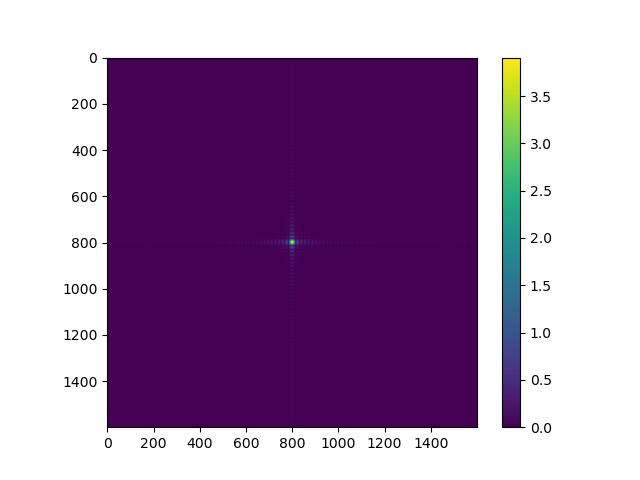

In [10]:
plt.figure()
plt.imshow(np.abs(probe))
plt.colorbar()

In [11]:
N = get_dims(na,wavelength,object_size)

In [12]:
print(f'pixel size in real space: {object_size/N*1e3} nm')

pixel size in real space: 1.25 nm


In [13]:
from skimage.draw import disk, polygon

def create_shape(size):
    """Generates different shapes as binary masks."""
    shape_mask = np.zeros((size, size))
    center = (size // 2, size // 2)
    
    r = np.array([size * 0.2, size * 0.8, size * 0.8])
    c = np.array([size * 0.5, size * 0.2, size * 0.8])
    rr, cc = polygon(r, c)
    shape_mask[rr, cc] = .2

    object_support = np.where(shape_mask>.1, 1.0,0)
    
    rr, cc = disk(center, size//10, shape=shape_mask.shape)
    shape_mask[rr, cc] = 0.5
    
    return 1-shape_mask, object_support



In [14]:
def generate_phase_profile(size, phase_type="gradient", phase_max=np.pi, period = 4):
    """Generates a phase profile of the given size."""
    x, y = np.meshgrid(np.linspace(-1, 1, size), np.linspace(-1, 1, size))
    
    if phase_type == "gradient":
        phase_profile = phase_max * x  # Linear gradient in the x-direction
    elif phase_type == "gaussian":
        phase_profile = phase_max * np.exp(-(x**2 + y**2) / 0.5)  # Gaussian phase profile
    elif phase_type == "random":
        phase_profile = np.random.uniform(0, phase_max, (size, size))  # Random phase
    elif phase_type == "sinusoidal":
        phase_profile = phase_max/2 * (np.sin(period * np.pi * x) + np.sin(period*np.pi*y))
    else:
        raise ValueError("Unsupported phase type")
    
    return phase_profile


In [15]:
object_amp, object_support = create_shape(X.shape[0])
object_pha = generate_phase_profile(X.shape[0], phase_type= 'sinusoidal') * object_support
complex_object = object_amp*np.exp(1j*object_pha)

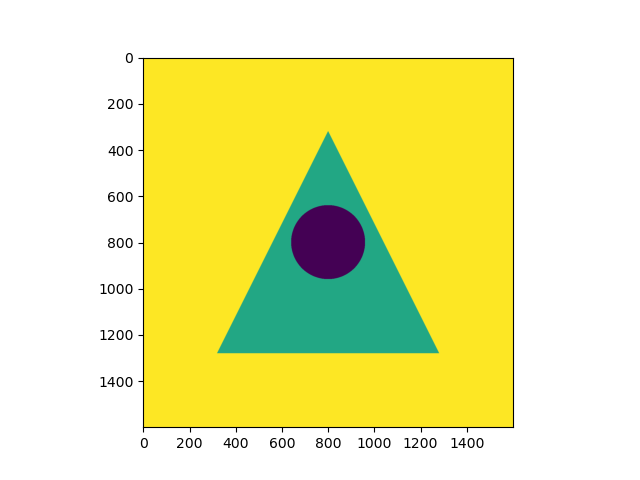

In [16]:
plt.figure()
plt.imshow( object_amp)

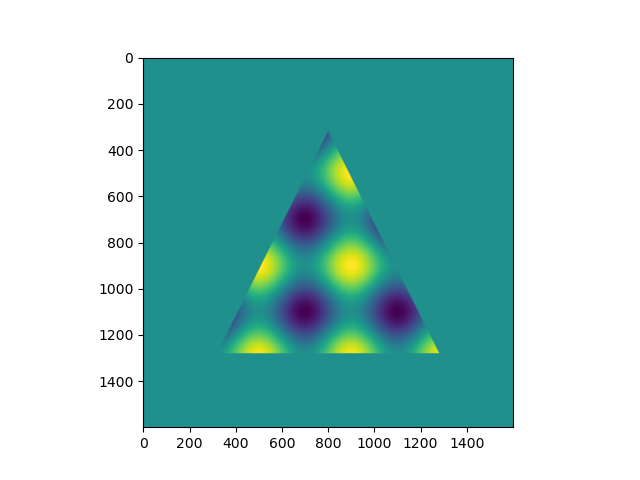

In [17]:
plt.figure()
plt.imshow(np.angle(complex_object))

In [18]:
# ptychography ~________

In [19]:
def generate_scan_positions(N, step):
    """Generates a scan grid over the object."""
    positions = [(x, y) for x in range(0, N , step) for y in range(0, N , step)]
    return positions

In [20]:
positions = generate_scan_positions(X.shape[0], 100)


In [21]:
len(positions)

256

In [22]:
import scipy 

def simulate_exit_wave(complex_object, probe, scan_positions):
    """Simulates the exit wave for different scan positions."""
    
    centre = np.array(complex_object.shape)//2
    print(centre)
    exit_waves = []
    
    for position in scan_positions:
        
        shift = centre - np.array(position)
        
        shfited_object = scipy.ndimage.shift(complex_object, shift[::-1], mode='constant', cval = 1.0)  
        exit_wave = shfited_object*probe
        
        exit_waves.append(exit_wave)
    
    return exit_waves


In [23]:
from joblib import Parallel, delayed
import scipy 
def simulate_one_pattern(complex_object, probe, scan_position):
    
    centre = np.array(complex_object.shape)//2
    shift = centre - np.array(scan_position)
    shfited_object = scipy.ndimage.shift(complex_object, shift[::-1], mode='constant', cval = 1.0)  
    exit_wave = shfited_object*probe

    fft_exit_wave = forward_fft(exit_wave)
    diff_pattern = np.abs(fft_exit_wave)**2
    
    return diff_pattern

def simulate_parallel_patterns(complex_object, probe, scan_positions):
    
    patterns = Parallel(n_jobs=-1)(
        delayed(simulate_one_pattern)(complex_object, probe, position) for position in scan_positions
    )
    return np.array(patterns)
    
    

In [24]:
def simulate_dataset(complex_object, probe, scan_positions):
    """
    Returns a 4D dataset: (Ny, Nx, qy, qx).
    """
    # simulate exit waves
    patterns = simulate_parallel_patterns(complex_object, probe, scan_positions)
    
    # reshape into 4D (Ny_scan, Nx_scan, qy, qx)
    Nx = len(np.unique([p[0] for p in scan_positions]))
    Ny = len(np.unique([p[1] for p in scan_positions]))
    qy, qx = patterns[0].shape
    
    dataset = patterns.reshape(Ny, Nx, qy, qx)
    return dataset

In [25]:
data_4d = simulate_dataset(complex_object, probe, positions)


In [26]:
import ipywidgets as widgets


def plot_list_slider(img_list):
    """Displays a list of coherent images and allows scrolling through them via a slider."""
    num_images = len(img_list)  # Number of images in the list
    
    # Create a slider for selecting the image index
    img_slider = widgets.IntSlider(min=0, max=num_images - 1, value=0, description="Image")

    # Create figure & axis once
    fig, ax = plt.subplots(figsize=(6, 6))
       
    im = ax.imshow(img_list[0], cmap='viridis')
    ax.set_title(f"Image {0}/{num_images - 1}")
    plt.colorbar(im, ax=ax, label="Intensity")
    plt.tight_layout()
    
    def update_image(img_idx):
        img = img_list[img_idx]        
        im.set_data(img)  # Update image data        
        ax.set_title(f"Image {img_idx}/{num_images - 1}")  # Update title
        fig.canvas.draw_idle()  # Efficient redraw

    interactive_plot = widgets.interactive(update_image, img_idx=img_slider)

    display(interactive_plot)  # Show slider


In [28]:
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display

def plot_4d_dataset(data_4d, pupil_roi=None):

    if pupil_roi is not None:
        data_4d = data_4d[:,:,pupil_roi[0]:pupil_roi[1], pupil_roi[2]:pupil_roi[3]]
        
    # Get dataset dimensions
    coherent_shape = data_4d.shape[:2]  
    detector_shape = data_4d.shape[2:]  
        
    # Set slider limits
    pcol_slider = widgets.IntSlider(min=0, max= detector_shape[1] - 1, value=detector_shape[1]//2, description="px")
    prow_slider = widgets.IntSlider(min=0, max= detector_shape[0] - 1, value=detector_shape[0]//2, description="py")
    
    lcol_slider = widgets.IntSlider(min=0, max= coherent_shape[1] - 1, value=coherent_shape[1]//2, description="lx")
    lrow_slider = widgets.IntSlider(min=0, max= coherent_shape[0] - 1, value=coherent_shape[0]//2, description="ly")


    rectangle_size_det = 4 
    rectangle_size_coh = .5
    
    # Create the figure and axes **only once**
    fig, axes = plt.subplots(1, 2, figsize=(12, 8))

    coherent_image = data_4d[:,:,prow_slider.value, pcol_slider.value].T
    detector_image = data_4d[lrow_slider.value, lcol_slider.value,:,:]

    
    im0 = axes[0].imshow(coherent_image, cmap='plasma')
    
    axes[0].set_title(f"Coherent Image (lx={lrow_slider.value}, ly={lcol_slider.value})")
    rect_coherent = Rectangle(( lcol_slider.value - rectangle_size_coh / 2, lrow_slider.value - rectangle_size_coh / 2), 
                              rectangle_size_coh, rectangle_size_coh, 
                              edgecolor='white', facecolor='white', lw=2)
    
    axes[0].add_patch(rect_coherent)
    plt.colorbar(im0, ax=axes[0], label="Intensity")

    im1 = axes[1].imshow(detector_image, cmap='viridis')
    axes[1].set_title(f"Detector Image (px={pcol_slider.value}, py={prow_slider.value})")
    rect_detector = Rectangle((pcol_slider.value - rectangle_size_det / 2, prow_slider.value - rectangle_size_det / 2), 
                              rectangle_size_det, rectangle_size_det, 
                              edgecolor='white', facecolor='white', lw=2)
    axes[1].add_patch(rect_detector)
    plt.colorbar(im1, ax=axes[1], label="Detector Intensity")

    plt.tight_layout()
    
    def update_plot(prow, pcol, lrow, lcol):
        """ Updates the plot based on slider values. """
        coherent_image = data_4d[:,:,prow,pcol].T
        detector_image = data_4d[lrow,lcol,:,:]

        im0.set_data(coherent_image)
        im1.set_data(detector_image)

        axes[0].set_title(f"Coherent Image from Pixel ({pcol}, {prow})")
        axes[1].set_title(f'Detector Image at Location ({lcol},{lrow})')
        
        # Update rectangles
        rect_coherent.set_xy((lcol - rectangle_size_coh / 2, lrow - rectangle_size_coh / 2))
        rect_detector.set_xy((pcol - rectangle_size_det / 2, prow - rectangle_size_det / 2))


        fig.canvas.draw_idle()
        
    # Create interactive widget
    interactive_plot = widgets.interactive(update_plot, prow=prow_slider, pcol=pcol_slider, lrow=lrow_slider, lcol=lcol_slider)
    
    controls = widgets.VBox([prow_slider, pcol_slider, lrow_slider, lcol_slider])
    display(interactive_plot)
    plt.show()

interactive(children=(IntSlider(value=100, description='py', max=199), IntSlider(value=100, description='px', …

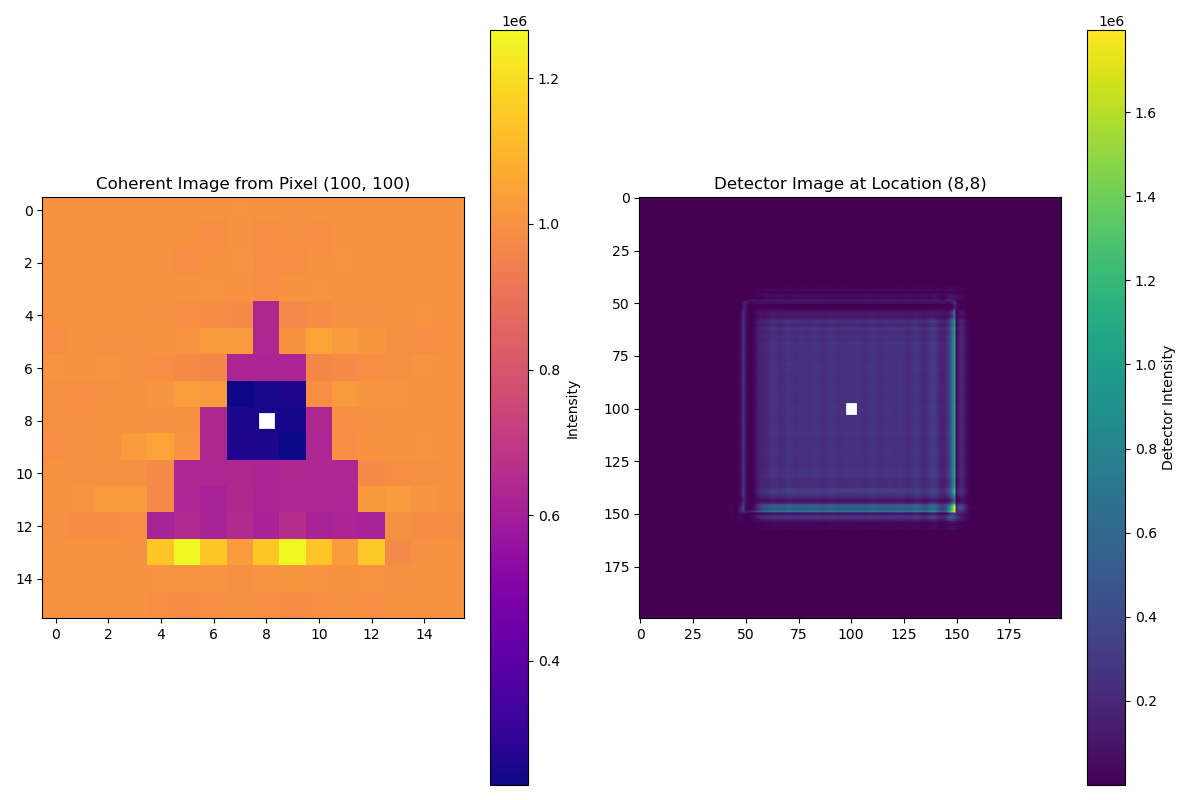

In [29]:
plot_4d_dataset(data_4d, pupil_roi=[700,900,700,900])

In [30]:
kX.shape

(1600, 1600)

In [41]:
def extract_pupil_roi(margin=10):
    """
    Extracts the region of interest (ROI) of the pupil 
    based on the known aperture width.

    Parameters
    ----------
    margin : int, optional
        Extra padding in pixels around the pupil. Default = 0.

    Returns
    -------
    pupil_roi : np.ndarray
        Cropped pupil region.
    kX_roi, kY_roi : np.ndarray
        Cropped coordinate grids.
    """

    # half-width of aperture in frequency space
    k_cutoff = na / wavelength * 2 * np.pi

    # find indices that fall within cutoff
    mask_x = np.where(np.abs(kX[0, :]) <= k_cutoff)[0]
    mask_y = np.where(np.abs(kY[:, 0]) <= k_cutoff)[0]

    x_min, x_max = mask_x.min(), mask_x.max()
    y_min, y_max = mask_y.min(), mask_y.max()

    # add margins safely
    x_min = max(0, x_min - margin)
    x_max = min(pupil.shape[1], x_max + margin + 1)
    y_min = max(0, y_min - margin)
    y_max = min(pupil.shape[0], y_max + margin + 1)

    pupil_roi = pupil[y_min:y_max, x_min:x_max]
    kX_roi = kX[y_min:y_max, x_min:x_max]
    kY_roi = kY[y_min:y_max, x_min:x_max]

    return pupil_roi, kX_roi, kY_roi


In [43]:
pupil_roi, kx_roi, ky_roi = extract_pupil_roi(margin=10)

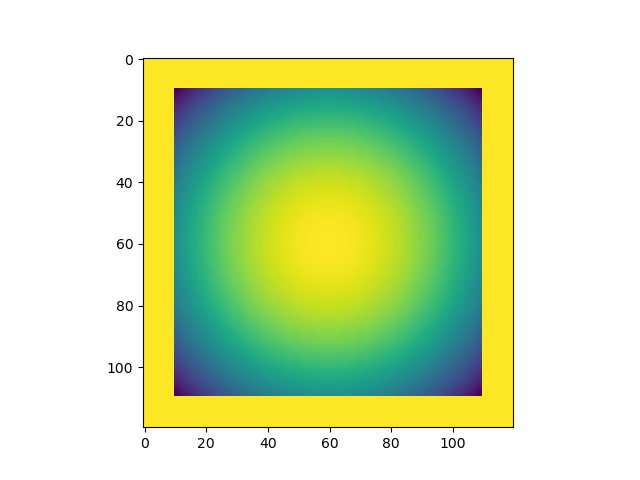

In [44]:
plt.figure()
plt.imshow(np.angle(pupil_roi))